In [5]:
import numpy as np  # for matrix operations
import pandas as pd # for data loading
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for plotting
sns.set_theme()

# Part 1

I will refer the feature matrix as `X` and dependent variable vector as `y` 

In [152]:
# Loading the data
training_data=pd.read_csv('FMLA1Q1Data_train.csv', header=None)
training_data.head()
X, y=training_data.drop(labels=2, axis=1), training_data[2]

Analyticial Solution is given by the below formula

$w_{ML}=(X^TX)^{-1}X^TY$

The `analytical_solution()` is the method that calculates the analytical solution.

In [7]:
# analytical solution
def analytical_solution(X, y, fit_bias=False):
    X_=X.copy()
    if fit_bias:
        X_['bias']=np.ones(shape=(X.shape[0], ))
    return (np.linalg.pinv(X_.T @ X_)) @ X_.T @ y

In [8]:
w_ml=analytical_solution(X, y)
w_ml.values

array([1.44599914, 3.88421178])

In [75]:
# method that calculates the gradient  of the OLS loss function with respect to a weight vector w
def gradient(X, y, w):
    return (X.T @ X @ w) - (X.T @ y)

def gradient_descent(X, y, iterations=1000, step_size=None):
    w=np.random.normal(scale=0.1, size=X.shape[1])
    errors=[]
    actual_iterations=0
    calc_step_size=lambda x: step_size
    if step_size is None:
        calc_step_size=lambda x: 1/(1+x) 
    for i in range(iterations):
        grad=gradient(X, y, w)
        if np.linalg.norm(grad)==0:
            break
        w=w-calc_step_size(actual_iterations)*grad
        errors.append(np.linalg.norm(w_ml-w))
        actual_iterations+=1
    return w, errors, actual_iterations


In [87]:
w, errors, iterations=gradient_descent(X, y, step_size=0.0001, iterations=200)
w, iterations

(0    1.445999
 1    3.884212
 dtype: float64,
 200)

In [88]:
iterations

200

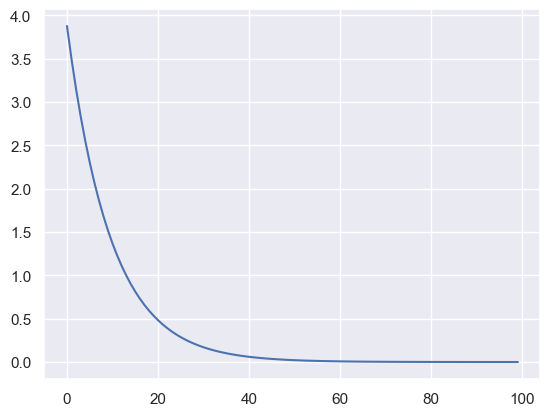

In [90]:
plt.plot(list(range(iterations))[:100], errors[:100])

In [91]:
def stochastic_gradient_descent(X, y, iterations=1000, step_size=None):
    w=np.random.normal(scale=0.1, size=X.shape[1])
    result=w.copy()
    errors=[]
    actual_iterations=0
    rng=np.random.default_rng(seed=3)
    converged=False
    calc_step_size=lambda x: step_size
    if step_size is None:
        calc_step_size=lambda x: 1/(1+x) 
    while (not converged) and (actual_iterations<iterations):
        index=np.arange(stop=X.shape[0])
        rng.shuffle(index)
        factor=100
        while ((factor-100)<index.shape[0]) and (actual_iterations<iterations):
            X_, y_=X.iloc[index[factor-100:factor], :], y.iloc[index[factor-100:factor]]
            grad=gradient(X_, y_, w)
            if np.linalg.norm(grad)==0:
                converged=True
                break
            w=w-calc_step_size(actual_iterations)*grad
            result+=w
            errors.append(np.linalg.norm(w_ml-w))
            actual_iterations+=1
            factor+=100
    return result/actual_iterations, errors, actual_iterations


In [101]:
w, errors, iterations=stochastic_gradient_descent(X, y, step_size=0.008, iterations=1000)
w

0    1.455549
1    3.894052
dtype: float64

In [102]:
iterations

1000

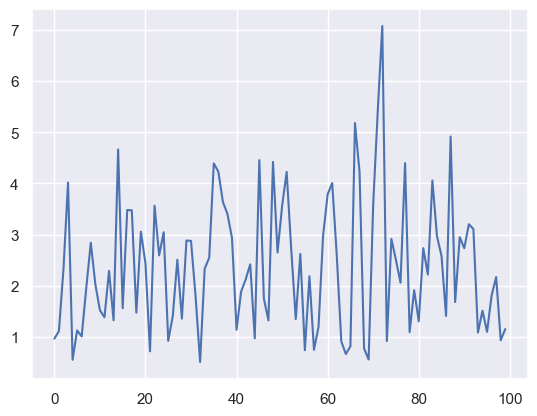

In [106]:
plt.plot(list(range(iterations))[:100], errors[:100])

In [131]:
def ridge_gradient(X, y, w, alpha):
    return gradient(X, y, w) + alpha*w

def ridge_gradient_descent(X, y, iterations=1000, step_size=None, alpha=0):
    w=np.random.normal(scale=0.1, size=X.shape[1])
    errors=[]
    actual_iterations=0
    calc_step_size=lambda x: step_size
    if step_size is None:
        calc_step_size=lambda x: 1/(1+x) 
    for i in range(iterations):
        grad=ridge_gradient(X, y, w, alpha)
        if np.linalg.norm(grad)==0:
            break
        w=w-calc_step_size(actual_iterations)*grad
        errors.append(np.linalg.norm(w_ml-w))
        actual_iterations+=1
    return w, errors, actual_iterations

def mse(y_true, y_pred):
    return np.sum((y_true-y_pred)**2)/y_true.shape[0]

def predict(X, w):
    return X @ w



In [132]:
w, errors, iterations=ridge_gradient_descent(X, y, step_size=0.0001, iterations=1000, alpha=1000)
w

0    0.712084
1    1.935888
dtype: float64

In [128]:
iterations

1000

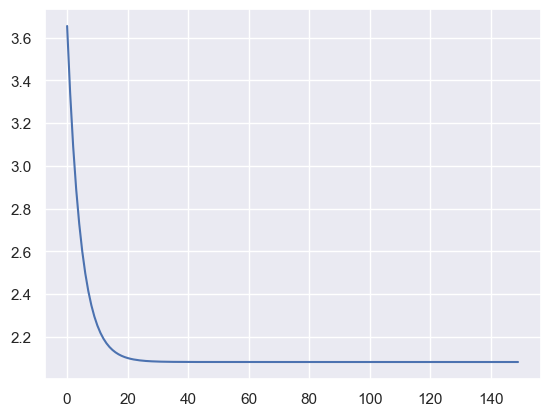

In [133]:
plt.plot(list(range(iterations))[:150], errors[:150])

In [231]:
errors=[]
for alpha in range(0, 1000, 100):
   pass

def genrate_splits(n, test_size):
   rng=np.random.default_rng(seed=3)
   index=np.arange(n)
   rng.shuffle(index)
   factor=int(n*test_size)+1
   iterations=0
   while (factor*iterations < index.shape[0]):
      test_index=index[iterations*factor : (iterations+1)*factor]
      train_index=~np.isin(index, test_index)
      yield train_index, test_index
      iterations+=1
   


def cross_validate(X, y, alpha, test_size):
   iterations=0
   errors=0
   for train_index, validation_index in genrate_splits(X.shape[0], test_size):
      X_train, X_valid, y_train, y_valid=X.loc[train_index, :], X.iloc[validation_index, :], y[train_index], y.iloc[validation_index]
      w=ridge_gradient_descent(X_train, y_train, step_size=0.0001, alpha=alpha)[0]
      predictions=predict(X_valid, w)
      errors+=mse(y_valid, predictions)
      iterations+=1

   return errors/iterations

In [232]:
ridge_gradient_descent(X, y, step_size=0.0001, alpha=20)[0]

0    1.416804
1    3.807568
dtype: float64

In [233]:
cross_validate(X, y, 20, 0.2)

221.81177310154425

In [225]:
alphas = np.arange(0, 40, 2)
errors=[]
for alpha in alphas:
    errors.append(cross_validate(X, y, alpha, 0.2))

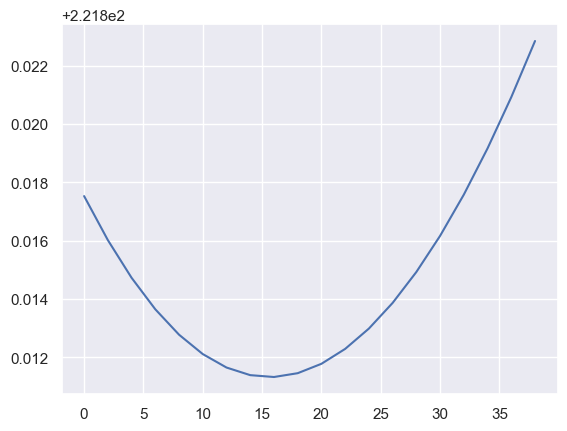

In [227]:
plt.plot(alphas, errors)

In [229]:
w_ridge=ridge_gradient_descent(X, y, step_size=0.0001, alpha=16)[0]
w_ridge

0    1.422548
1    3.822654
dtype: float64

In [228]:
testing_data=pd.read_csv('FMLA1Q1Data_test.csv', header=None)
X_test, y_test=testing_data.drop(labels=2, axis=1), testing_data[2]

In [230]:
predictions_ml=predict(X_test, w_ml)
error_ml=mse(y_test, predictions_ml)

predictions_ridge=predict(X_test, w_ridge)
error_ridge=mse(y_test, predictions_ridge)
print('Error ML : %1.3f'%error_ml)
print('Error Ridge : %1.3f'%error_ridge)

Error ML : 142.766
Error Ridge : 142.830


In [234]:
np.linalg.pinv((X.T @ X) + 16*np.eye(2)) @ X.T @ y

0    1.422548
1    3.822654
dtype: float64